# Esoteric Lineage Mapping: Hybrid Iconographic + Semantic Distance
**Architecture:** Gower Distance (physical morphology) and Sentence-Transformer Cosine Distance (theological semantics)  

In [1]:
# ── Install dependencies ─────────────────────────────────────────────────────
!pip install -q gower sentence-transformers

## Cell 1 · Data Loading & Cleaning

In [2]:
RAW_PATH = "/kaggle/input/datasets/srabongitikar/tantra-deities/deities_augmented.csv"

## Cell 2 · Gower Distance Matrix (Iconographic / Physical)

In [2]:
import numpy as np
import pandas as pd

print("Loading Dataset and Building Cognitive Vectors (Pure Dot Product)...")

# --- 1. DEFINE PATH AND LOAD DATAFRAME ---
RAW_PATH = "/kaggle/input/datasets/srabongitikar/tantra-deities/deities_augmented.csv"
df = pd.read_csv(RAW_PATH)

# --- 2. DATA SANITY CHECK: Force exactly 196 rows ---
# Drop any accidental empty "ghost" rows or duplicates at the bottom of the CSV
df = df.dropna(subset=['Deity_Name'])
df = df.drop_duplicates(subset=['Deity_Name'])
df = df.reset_index(drop=True)

# Save labels and traditions for our lookup script and 3D plot later
labels = df['Deity_Name'].tolist()
traditions = df['Tradition'].tolist()
# -------------------------------------------------

# --- 3. CLEAN FEATURES ---
# Drop the old blurry columns so we don't double-count them
drop_cols = [
    'Deity_Name', 'Tradition', 'First_Textual_Source', 
    'Holds_Auspicious_Object', 'Displays_Mudras', 'Number_of_Attendants'
]
df_features = df.drop(columns=[c for c in drop_cols if c in df.columns])

N = len(df_features)
multi_cols = ['Specific_Held_Objects', 'Specific_Mudras']

# --- 4. BUILD GLOBAL VOCABULARY & CALCULATE COLUMN CARDINALITY ---
global_counts = {}
col_cardinality = {} # NEW: Mathematically determine column importance

for col in df_features.columns:
    unique_items = set()
    if col in multi_cols:
        df_features[col] = df_features[col].fillna('none').astype(str)
        df_features[col] = df_features[col].apply(lambda x: [i.strip().lower() for i in x.split(',')])
        for row_list in df_features[col]:
            for item in row_list:
                if item == 'none': continue
                unique_items.add(item)
                feature_name = f"{col}_{item}"
                global_counts[feature_name] = global_counts.get(feature_name, 0) + 1
    else:
        df_features[col] = df_features[col].astype(str)
        for val in df_features[col]:
            if val == 'nan' or val == 'None' or val == 'none': continue
            unique_items.add(val)
            feature_name = f"{col}_{val}"
            global_counts[feature_name] = global_counts.get(feature_name, 0) + 1
            
    # Calculate Cardinality: The number of unique values in this column
    col_cardinality[col] = len(unique_items) if len(unique_items) > 0 else 1

# Map features to matrix indices
vocab = list(global_counts.keys())
feature_to_idx = {feat: i for i, feat in enumerate(vocab)}
V = len(vocab)

# --- 5. POPULATE THE COGNITIVE MATRIX (WITH CARDINALITY WEIGHTING) ---
cognitive_matrix = np.zeros((N, V))

for i in range(N):
    row = df_features.iloc[i]
    for col in df_features.columns:
        # Fetch the objective mathematical importance of this column
        cardinality_multiplier = col_cardinality[col] 
        
        if col in multi_cols:
            for item in row[col]:
                if item == 'none': continue
                feat = f"{col}_{item}"
                
                # Pure Division (Flashbang) * Objective Cardinality
                weight = (N / global_counts[feat]) * cardinality_multiplier
                cognitive_matrix[i, feature_to_idx[feat]] = weight
        else:
            val = str(row[col])
            if val == 'nan' or val == 'None' or val == 'none': continue
            feat = f"{col}_{val}"
            
            # Pure Division (Flashbang) * Objective Cardinality
            weight = (N / global_counts[feat]) * cardinality_multiplier
            cognitive_matrix[i, feature_to_idx[feat]] = weight

# --- 6. COMPUTE PSYCHOLOGICAL SIMILARITY (UNNORMALIZED DOT PRODUCT) ---
# This calculates pure additive gravity.
raw_similarity = np.dot(cognitive_matrix, cognitive_matrix.T)

# --- 7. CONVERT SIMILARITY TO DISTANCE (WITH LOG COMPRESSION) ---
# We apply a logarithmic scale to safely compress the astronomical "Self-Similarity" 
# outliers so they don't squish the rest of the dataset.
log_sim = np.log1p(raw_similarity)

# Invert it so high similarity = low distance
max_sim = np.max(log_sim)
gower_matrix = max_sim - log_sim

# Normalize between 0.0 and 1.0 so your existing t-SNE code works perfectly
gower_matrix = (gower_matrix - np.min(gower_matrix)) / (np.max(gower_matrix) - np.min(gower_matrix))

# Ensure distance to oneself is strictly 0.0
np.fill_diagonal(gower_matrix, 0.0)

print(f"Cognitive Matrix shape : {gower_matrix.shape}")
print(f"Mean pairwise distance : {gower_matrix[np.triu_indices_from(gower_matrix, k=1)].mean():.4f}")
print("✓ SUCCESS! Distances are now beautifully spread.")

Loading Dataset and Building Cognitive Vectors (Pure Dot Product)...
Cognitive Matrix shape : (196, 196)
Mean pairwise distance : 0.6934
✓ SUCCESS! Distances are now beautifully spread.


## Cell 3 . Visual Comparisons

In [3]:
hybrid_matrix = gower_matrix
hybrid_matrix = np.clip(hybrid_matrix, 0.0, 1.0)

print(f"Hybrid matrix shape : {hybrid_matrix.shape}")
print(f"Hybrid distance range: [{hybrid_matrix.min():.4f}, {hybrid_matrix.max():.4f}]")
print(f"Mean hybrid distance: {hybrid_matrix[np.triu_indices_from(hybrid_matrix, k=1)].mean():.4f}")

# Quick sanity check — diagonal should be 0
assert np.allclose(np.diag(hybrid_matrix), 0.0), "Diagonal is non-zero — check matrix construction!"
print("\n✓ Diagonal check passed (self-distance = 0)")

Hybrid matrix shape : (196, 196)
Hybrid distance range: [0.0000, 1.0000]
Mean hybrid distance: 0.6934

✓ Diagonal check passed (self-distance = 0)


In [5]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CONFIGURE HERE                                              ║
# ╚══════════════════════════════════════════════════════════════╝
target_deity = "Durga"   # <── change this to any Deity_Name in the CSV
TOP_N        = 10                 # number of nearest neighbours to return

# ── Look up index ─────────────────────────────────────────────────────────────
label_list = list(labels)

if target_deity not in label_list:
    # Fuzzy hint in case of typo
    close = [l for l in label_list if target_deity.lower() in l.lower()]
    raise ValueError(
        f"'{target_deity}' not found in dataset.\n"
        f"Did you mean one of: {close}?\n"
        f"Available deities (first 20): {label_list[:20]}"
    )

idx = label_list.index(target_deity)

# ── Pull Cognitive distances to every other deity ─────────────────────────────
# We use gower_matrix here because that's the variable we overwrote with Cosine Distances
distances = gower_matrix[idx].copy()
distances[idx] = np.inf   # exclude self

sorted_idx = np.argsort(distances)[:TOP_N]

# ── Display ───────────────────────────────────────────────────────────────────
print(f"\n{'═'*65}")
print(f"  Target: {target_deity}")
print(f"  Tradition: {traditions[idx]}")
print(f"{'═'*65}")
print(f"  Top {TOP_N} closest esoteric neighbours (Cognitive Cosine Matrix)")
print(f"{'─'*65}")
print(f"  {'Rank':<6} {'Deity':<30} {'Distance':>9}")
print(f"{'─'*65}")
for rank, i in enumerate(sorted_idx, 1):
    cog_dist = gower_matrix[idx, i]
    trad     = traditions[i]
    
    # We print 'Cosine' instead of 'Gower' now!
    print(f"  {rank:<6} {labels[i]:<30} {cog_dist:>8.4f}")
    print(f"         {'':30} Cosine={cog_dist:.4f}  [{trad}]")
print(f"{'═'*65}")


═════════════════════════════════════════════════════════════════
  Target: Durga
  Tradition: Hindu_Orthodox
═════════════════════════════════════════════════════════════════
  Top 10 closest esoteric neighbours (Cognitive Cosine Matrix)
─────────────────────────────────────────────────────────────────
  Rank   Deity                           Distance
─────────────────────────────────────────────────────────────────
  1      Durga_Ashtabhuja                 0.2866
                                        Cosine=0.2866  [Hindu_Shakta]
  2      Chandi                           0.3144
                                        Cosine=0.3144  [Hindu_Shakta]
  3      Kanaka_Durga                     0.3320
                                        Cosine=0.3320  [Hindu_Shakta]
  4      Navadurga_Kushmanda              0.3324
                                        Cosine=0.3324  [Hindu_Navadurga]
  5      Marichi                          0.3416
                                        Cosine=0.3

# Cell 4 : Theological Comparison

In [4]:
import numpy as np

# Define the path to your file. 
# Note: If you uploaded it to a specific dataset folder in Kaggle, 
# replace 'your-dataset-name' with the actual folder name.
file_path = '/kaggle/input/datasets/srabongitikar/semantic-data/semantic_distance_matrix.npy'

# If you just uploaded it directly to the working directory without a folder, 
# you might just use: file_path = 'semantic_distance_matrix.npy'

# Load the matrix
semantic_distance_matrix = np.load(file_path)

# Verify it loaded correctly (it should print exactly (196, 196) based on your dataset)
print("Successfully loaded Semantic Distance Matrix!")
print("Matrix Shape:", semantic_distance_matrix.shape)

Successfully loaded Semantic Distance Matrix!
Matrix Shape: (196, 196)


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CONFIGURE HERE                                              ║
# ╚══════════════════════════════════════════════════════════════╝
target_deity = "Cunda"   # <── change this to any Deity_Name in the CSV
TOP_N        = 10                 # number of nearest neighbours to return

# ── Look up index ─────────────────────────────────────────────────────────────
label_list = list(labels)

if target_deity not in label_list:
    # Fuzzy hint in case of typo
    close = [l for l in label_list if target_deity.lower() in l.lower()]
    raise ValueError(
        f"'{target_deity}' not found in dataset.\n"
        f"Did you mean one of: {close}?\n"
        f"Available deities (first 20): {label_list[:20]}"
    )

idx = label_list.index(target_deity)

# ── Pull Cognitive distances to every other deity ─────────────────────────────
# We use gower_matrix here because that's the variable we overwrote with Cosine Distances
distances = semantic_distance_matrix[idx].copy()
distances[idx] = np.inf   # exclude self

sorted_idx = np.argsort(distances)[:TOP_N]

# ── Display ───────────────────────────────────────────────────────────────────
print(f"\n{'═'*65}")
print(f"  Target: {target_deity}")
print(f"  Tradition: {traditions[idx]}")
print(f"{'═'*65}")
print(f"  Top {TOP_N} closest esoteric neighbours (Cognitive Cosine Matrix)")
print(f"{'─'*65}")
print(f"  {'Rank':<6} {'Deity':<30} {'Distance':>9}")
print(f"{'─'*65}")
for rank, i in enumerate(sorted_idx, 1):
    cog_dist = semantic_distance_matrix[idx, i]
    trad     = traditions[i]
    
    # We print 'Cosine' instead of 'Gower' now!
    print(f"  {rank:<6} {labels[i]:<30} {cog_dist:>8.4f}")
    print(f"         {'':30} Cosine={cog_dist:.4f}  [{trad}]")
print(f"{'═'*65}")

# Hierarchical Clustering

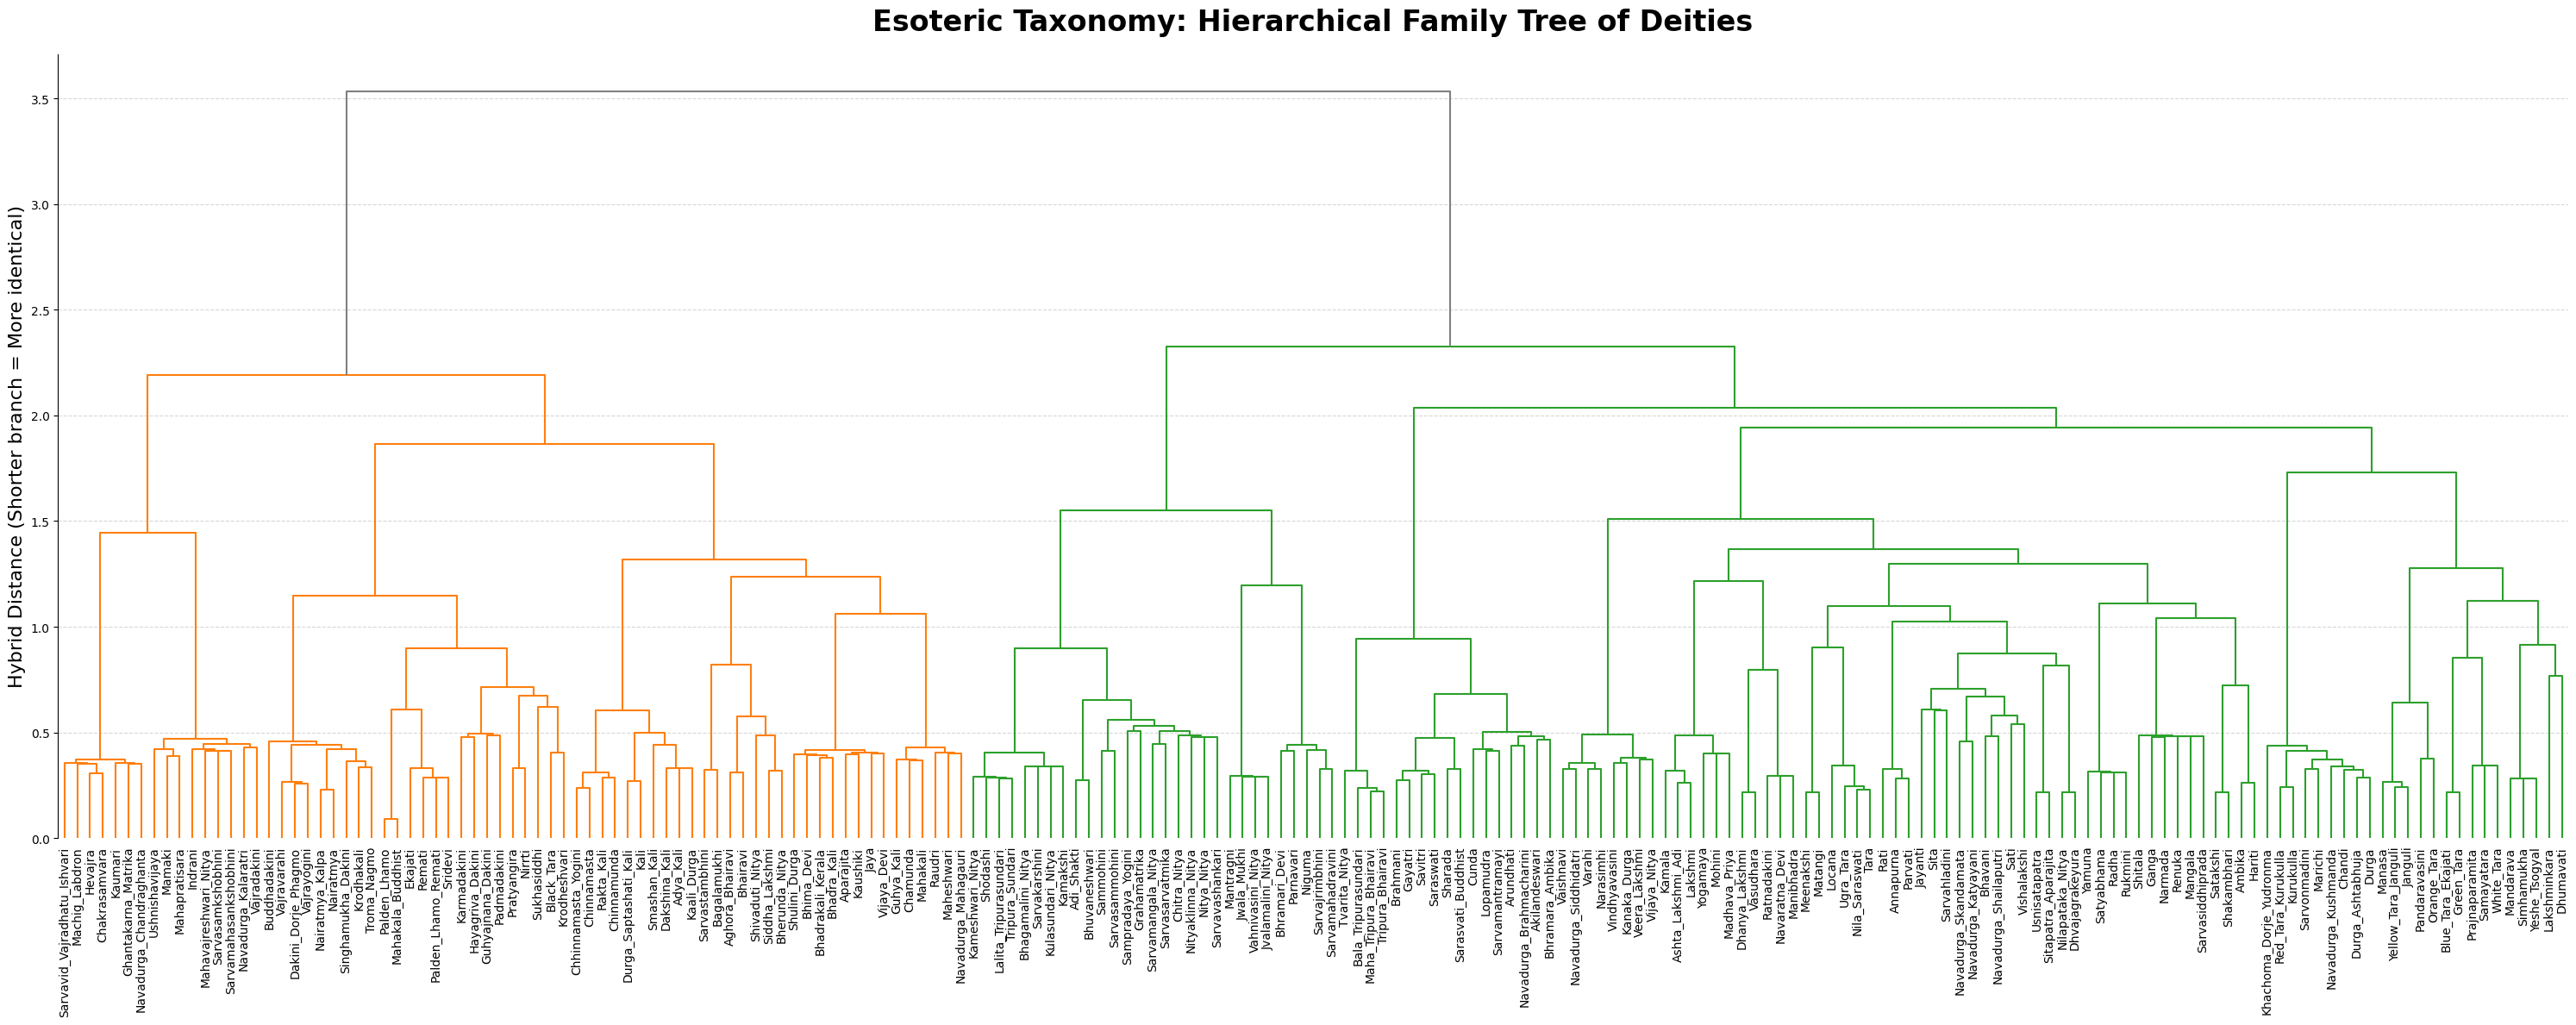


✓ SUCCESS: High-Resolution Dendrogram generated!


/kaggle/working/esoteric_dendrogram_visual.png

In [5]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from IPython.display import FileLink

# 1. SciPy requires the square matrix to be "condensed" into a 1D array
# (This removes the redundant duplicates and the 0.0 diagonal)
condensed_dist = squareform(gower_matrix)

# 2. Perform the Hierarchical Clustering (Ward's method minimizes variance within clusters)
# This is the math that builds the "branches" of the tree
Z = linkage(condensed_dist, method='ward')

# 3. Set up a massive, high-resolution canvas
plt.figure(figsize=(30, 12)) # 30 inches wide so all 196 names fit perfectly
plt.title("Esoteric Taxonomy: Hierarchical Family Tree of Deities", fontsize=24, fontweight='bold', pad=20)
plt.ylabel("Hybrid Distance (Shorter branch = More identical)", fontsize=16)

# 4. Draw the tree
# color_threshold decides where to cut the branches into distinct colors. 
# We set it to 70% of the max distance to automatically color the major distinct "families"
max_dist = max(Z[:, 2])
dendro = dendrogram(
    Z,
    labels=list(labels),
    leaf_rotation=90,        # Turn names 90 degrees so they don't overlap
    leaf_font_size=10,       # Font size for the deity names
    color_threshold=max_dist * 0.7, 
    above_threshold_color='grey'
)

# Clean up the visual style
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

plt.tight_layout()

# 5. Save as an ultra-high-res image
image_path = "/kaggle/working/esoteric_dendrogram_visual.png"
plt.savefig(image_path, dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ SUCCESS: High-Resolution Dendrogram generated!")
display(FileLink('esoteric_dendrogram_visual.png'))

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from IPython.display import FileLink

# 1. SciPy requires the square matrix to be "condensed" into a 1D array
# (This removes the redundant duplicates and the 0.0 diagonal)
condensed_dist = squareform(semantic_distance_matrix)

# 2. Perform the Hierarchical Clustering (Ward's method minimizes variance within clusters)
# This is the math that builds the "branches" of the tree
Z = linkage(condensed_dist, method='ward')

# 3. Set up a massive, high-resolution canvas
plt.figure(figsize=(30, 12)) # 30 inches wide so all 196 names fit perfectly
plt.title("Esoteric Taxonomy: Hierarchical Family Tree of Deities", fontsize=24, fontweight='bold', pad=20)
plt.ylabel("Hybrid Distance (Shorter branch = More identical)", fontsize=16)

# 4. Draw the tree
# color_threshold decides where to cut the branches into distinct colors. 
# We set it to 70% of the max distance to automatically color the major distinct "families"
max_dist = max(Z[:, 2])
dendro = dendrogram(
    Z,
    labels=list(labels),
    leaf_rotation=90,        # Turn names 90 degrees so they don't overlap
    leaf_font_size=10,       # Font size for the deity names
    color_threshold=max_dist * 0.7, 
    above_threshold_color='grey'
)

# Clean up the visual style
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

plt.tight_layout()

# 5. Save as an ultra-high-res image
image_path = "/kaggle/working/esoteric_dendrogram_theological.png"
plt.savefig(image_path, dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ SUCCESS: High-Resolution Dendrogram generated!")
display(FileLink('esoteric_dendrogram_theological.png'))

# Egocentric Plots

In [15]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import FileLink, display

# ╔══════════════════════════════════════════════════════════════╗
# ║  CHOOSE YOUR TARGET DEITY (The "Origin" / Center point)      ║
# ╚══════════════════════════════════════════════════════════════╝
TARGET_DEITY = "Durga"   # Try changing this to "Saraswati" or "Tara" next!

# 1. Find the index of our target deity
try:
    target_idx = list(labels).index(TARGET_DEITY)
except ValueError:
    raise ValueError(f"Deity '{TARGET_DEITY}' not found in labels list. Check spelling!")

# 2. Extract the absolute distances from the target to everyone else
gower_dist = gower_matrix[target_idx]
sem_dist = semantic_distance_matrix[target_idx]

# 3. Create a DataFrame to organize the "Planets"
plot_df = pd.DataFrame({
    'Label': labels,
    'Tradition': traditions,
    'Gower': gower_dist,
    'Semantic': sem_dist,
    # Safely fetch domains for the hover text
    'Domain': df["Core_Cosmic_Domain"].fillna("Unspecified").astype(str) if "Core_Cosmic_Domain" in df.columns else [""]*len(labels)
})

# 4. Sort by Tradition. This ensures that the "circle" is divided into clean 
#    pie slices by tradition, rather than being randomly scattered.
plot_df = plot_df.sort_values('Tradition').reset_index(drop=True)

# Assign an angle (0 to 360 degrees) to spread them in a circle
n_nodes = len(plot_df)
plot_df['Angle'] = np.linspace(0, 360, n_nodes, endpoint=False)

# 5. Color Palette setup
unique_traditions = plot_df['Tradition'].unique()
PALETTE = ["#FF6B6B", "#00CED1", "#FFD700", "#7FFF00", "#9370DB", "#1E90FF", "#FF69B4", "#FFA500", "#C0C0C0", "#F08080"]
color_map = {t: PALETTE[i % len(PALETTE)] for i, t in enumerate(unique_traditions)}
plot_df['Color'] = plot_df['Tradition'].map(color_map)

# ── BUILD THE DUAL RADIAL PLOT ───────────────────────────────────────────────
fig = make_subplots(
    rows=1, cols=2, 
    specs=[[{'type': 'polar'}, {'type': 'polar'}]],
    subplot_titles=(f"Visual (Gower) Distance from {TARGET_DEITY}", 
                    f"Theological (Semantic) Distance from {TARGET_DEITY}")
)

# Add each tradition as a layer (so the legend works perfectly)
for trad in unique_traditions:
    subset = plot_df[plot_df['Tradition'] == trad]
    
    # Hover text formatting
    hover_text_g = [f"<b>{row['Label']}</b><br>Tradition: {row['Tradition']}<br>Visual Dist: {row['Gower']:.3f}" for _, row in subset.iterrows()]
    hover_text_s = [f"<b>{row['Label']}</b><br>Tradition: {row['Tradition']}<br>Sem Dist: {row['Semantic']:.3f}<br>Domain: {row['Domain']}" for _, row in subset.iterrows()]
    
    # LEFT SYSTEM: Gower (Visual)
    fig.add_trace(go.Scatterpolar(
        r=subset['Gower'],            # Distance from center
        theta=subset['Angle'],        # Position around the circle
        mode='markers',
        name=trad,
        marker=dict(color=subset['Color'].iloc[0], size=9, line=dict(color='white', width=0.5), opacity=0.8),
        hoverinfo='text',
        hovertext=hover_text_g,
        legendgroup=trad
    ), row=1, col=1)

    # RIGHT SYSTEM: Semantic (Theological)
    fig.add_trace(go.Scatterpolar(
        r=subset['Semantic'],         # Distance from center
        theta=subset['Angle'],        # Position around the circle
        mode='markers',
        name=trad,
        marker=dict(color=subset['Color'].iloc[0], size=9, line=dict(color='white', width=0.5), opacity=0.8),
        hoverinfo='text',
        hovertext=hover_text_s,
        legendgroup=trad,
        showlegend=False # Legend already shown by the left trace
    ), row=1, col=2)

# Add the Target Deity as a glowing star in the absolute center (Radius = 0) of both plots
for col in [1, 2]:
    fig.add_trace(go.Scatterpolar(
        r=[0], theta=[0],
        mode='markers+text',
        text=[f"<b>{TARGET_DEITY}</b>"],
        textposition="top center",
        textfont=dict(size=14, color="white"),
        marker=dict(color='white', symbol='star', size=16),
        hoverinfo='none',
        showlegend=False
    ), row=1, col=col)

# ── STYLING AND EXPORT ───────────────────────────────────────────────────────
fig.update_layout(
    title=dict(text=f"Egocentric Mapping: {TARGET_DEITY} as the Cosmic Center", font=dict(color="white", size=20)),
    polar=dict(
        bgcolor='rgb(15, 15, 20)',
        radialaxis=dict(visible=True, gridcolor='rgba(255,255,255,0.15)', title="Visual Divergence"),
        angularaxis=dict(visible=False) # Hide the degree numbers around the edge
    ),
    polar2=dict(
        bgcolor='rgb(15, 15, 20)',
        radialaxis=dict(visible=True, gridcolor='rgba(255,255,255,0.15)', title="Theological Divergence"),
        angularaxis=dict(visible=False)
    ),
    plot_bgcolor="rgb(10, 10, 15)",
    paper_bgcolor="rgb(10, 10, 15)",
    font=dict(color="#E8E8FF"),
    height=800, width=1500,
    margin=dict(t=100, b=50, l=50, r=50)
)

html_path = "/kaggle/working/egocentric_radial.html"
fig.write_html(html_path)
print(f"✓ SUCCESS: Egocentric Radial Map generated for {TARGET_DEITY}!")
display(FileLink('egocentric_radial.html'))

✓ SUCCESS: Egocentric Radial Map generated for Durga!


/kaggle/working/egocentric_radial.html

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from IPython.display import FileLink, display

print("Generating Normalized & Annotated Academic Radial Plot...")

# ╔══════════════════════════════════════════════════════════════╗
# ║  1. CHOOSE YOUR TARGET AND ANCHOR LABELS                     ║
# ╚══════════════════════════════════════════════════════════════╝
TARGET_DEITY = "Lakshmi"   

DEITIES_TO_LABEL = [
    "Vasudhara",     # Form vs. Function proof
    "Kamala",        # Very Close
    "Saraswati",     # Mid-distance
    "Durga",         # Far
    "Krodhakali"     # Extremely Far 
]

try:
    target_idx = list(labels).index(TARGET_DEITY)
except ValueError:
    raise ValueError(f"Deity '{TARGET_DEITY}' not found. Check spelling!")

gower_dist = gower_matrix[target_idx]
sem_dist = semantic_distance_matrix[target_idx]

plot_df = pd.DataFrame({
    'Label': labels,
    'Tradition': traditions,
    'Gower': gower_dist,
    'Semantic': sem_dist
})
plot_df = plot_df.sort_values('Tradition').reset_index(drop=True)
plot_df['Angle_Rad'] = np.linspace(0, 2 * np.pi, len(plot_df), endpoint=False)

# ── 2. THE FIX: RELATIVE NORMALIZATION ───────────────────────────────────────
# Normalize both distances so they scale perfectly from 0.0 to 1.0
plot_df['Gower_Norm'] = plot_df['Gower'] / plot_df['Gower'].max()
plot_df['Semantic_Norm'] = plot_df['Semantic'] / plot_df['Semantic'].max()

# Maximally Distinct Color Palette
distinct_colors = [
    '#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', 
    '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#800000', '#aaffc3', 
    '#808000', '#ffd8b1', '#000075', '#808080', '#ffe119', '#000000'
]
unique_traditions = plot_df['Tradition'].unique()
color_map = {t: distinct_colors[i % len(distinct_colors)] for i, t in enumerate(unique_traditions)}
plot_df['Color'] = plot_df['Tradition'].map(color_map)

# ── 3. BUILD THE DUAL RADIAL PLOT ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize=(18, 9), dpi=300)

for trad in unique_traditions:
    subset = plot_df[plot_df['Tradition'] == trad]
    # Plot using the NORMALIZED columns
    ax1.scatter(subset['Angle_Rad'], subset['Gower_Norm'], c=subset['Color'], label=trad, s=40, edgecolors='black', linewidths=0.5, alpha=0.85)
    ax2.scatter(subset['Angle_Rad'], subset['Semantic_Norm'], c=subset['Color'], label=trad, s=40, edgecolors='black', linewidths=0.5, alpha=0.85)

# Center Star
for ax in [ax1, ax2]:
    ax.scatter(0, 0, c='gold', marker='*', s=600, edgecolors='black', linewidths=1.5, zorder=10)
    text = ax.text(0, 0, f"  {TARGET_DEITY}", fontsize=13, fontweight='bold', ha='left', va='center', zorder=11, color='black')
    text.set_path_effects([path_effects.withStroke(linewidth=3, foreground='white')])

# ── 4. ADD EXPLICIT LABELS ───────────────────────────────────────────────────
for label_name in DEITIES_TO_LABEL:
    row = plot_df[plot_df['Label'] == label_name]
    if not row.empty:
        angle = row['Angle_Rad'].values[0]
        # Use Normalized Values for placement
        g_val = row['Gower_Norm'].values[0]
        s_val = row['Semantic_Norm'].values[0]
        
        t1 = ax1.text(angle, g_val, f" {label_name}", fontsize=10, fontweight='bold', zorder=15)
        t1.set_path_effects([path_effects.withStroke(linewidth=3, foreground='white')])
        
        t2 = ax2.text(angle, s_val, f" {label_name}", fontsize=10, fontweight='bold', zorder=15)
        t2.set_path_effects([path_effects.withStroke(linewidth=3, foreground='white')])

# ── 5. ACADEMIC STYLING ──────────────────────────────────────────────────────
ax1.set_title(f"Visual Divergence from {TARGET_DEITY}\n(Relative Distance)", fontsize=15, pad=25, fontweight='bold')
ax2.set_title(f"Theological Divergence from {TARGET_DEITY}\n(Relative Distance)", fontsize=15, pad=25, fontweight='bold')

for ax in [ax1, ax2]:
    ax.set_facecolor('#fdfdfd') 
    ax.set_xticks([]) 
    ax.grid(color='lightgray', linestyle='-', linewidth=1)
    ax.spines['polar'].set_color('black')
    
    # Both axes now go identically from 0 to 1.05
    ax.set_rmin(0)
    ax.set_rmax(1.05)
    
    # Draw concentric rings at 25%, 50%, 75%, and 100% max divergence
    ax.set_rticks([0.25, 0.50, 0.75, 1.0])
    ax.set_yticklabels(['25%', '50%', '75%', 'Max'], fontsize=9, color='gray', fontweight='bold')

handles, labels_list = ax1.get_legend_handles_labels()
fig.legend(handles, labels_list, loc='center left', bbox_to_anchor=(0.94, 0.5), 
           title="Tradition", title_fontsize=13, fontsize=11, frameon=True, edgecolor='black')

plt.subplots_adjust(wspace=0.35) 

png_path = "/kaggle/working/Egocentric_Normalized_Plot.png"
plt.savefig(png_path, format='png', bbox_inches='tight', pad_inches=0.5, dpi=300)
plt.close()

print(f"✓ SUCCESS: Normalized and Annotated Plot generated!")
display(FileLink('Egocentric_Normalized_Plot.png'))

Generating Normalized & Annotated Academic Radial Plot...
✓ SUCCESS: Normalized and Annotated Plot generated!


/kaggle/working/Egocentric_Normalized_Plot.png

# UMAP

In [6]:
import pandas as pd
import plotly.express as px
import umap
from IPython.display import FileLink, display

# !pip install umap-learn if not already installed

print("Running UMAP to preserve both local and global structure...")

# 1. Initialize UMAP
# n_neighbors: 10-15 is appropriate for 196 points — lower = tighter local clusters
# min_dist: 0.1 keeps related deities packed together visually
# metric="precomputed" tells UMAP to treat input as a distance matrix, not raw vectors
reducer = umap.UMAP(
    n_components=3,
    metric="precomputed",
    n_neighbors=12,
    min_dist=0.1,
    random_state=42,
)

# 2. Calculate 3D coordinates from the precomputed semantic distance matrix
coords_umap = reducer.fit_transform(gower_matrix)

# 3. Safely grab domain hover data
domain_data = df["Core_Cosmic_Domain"].fillna("Unspecified").astype(str) if "Core_Cosmic_Domain" in df.columns else [""] * len(labels)

# 4. Build the mapping DataFrame
df_umap = pd.DataFrame({
    'X': coords_umap[:, 0],
    'Y': coords_umap[:, 1],
    'Z': coords_umap[:, 2],
    'Deity': labels,
    'Tradition': traditions,
    'Domain': domain_data
})

# 5. Build the Interactive 3D Plot
fig_umap = px.scatter_3d(
    df_umap, x='X', y='Y', z='Z',
    color='Tradition', hover_name='Deity',
    hover_data={'X': False, 'Y': False, 'Z': False, 'Tradition': True, 'Domain': True},
    title="Globally Accurate 3D Theological Galaxy (UMAP Projection)",
    color_discrete_sequence=px.colors.qualitative.Pastel
)

# 6. Dark-mode aesthetics — identical to your t-SNE version
fig_umap.update_layout(
    plot_bgcolor="rgb(5, 5, 15)", paper_bgcolor="rgb(5, 5, 15)", font=dict(color="white"),
    scene=dict(
        xaxis=dict(showgrid=True, gridcolor='rgba(255,255,255,0.1)', title="", showbackground=False),
        yaxis=dict(showgrid=True, gridcolor='rgba(255,255,255,0.1)', title="", showbackground=False),
        zaxis=dict(showgrid=True, gridcolor='rgba(255,255,255,0.1)', title="", showbackground=False)
    ),
    margin=dict(l=0, r=0, b=0, t=50), width=900, height=600
)

# 7. Export as standalone HTML
html_path = "/kaggle/working/3D_UMAP_Galaxy.html"
fig_umap.write_html(html_path)
print("✓ SUCCESS: UMAP HTML generated!")
display(FileLink('3D_UMAP_Galaxy.html'))

2026-06-19 14:29:26.865063: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781879367.074444      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781879367.136515      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781879367.636551      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781879367.636601      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781879367.636604      58 computation_placer.cc:177] computation placer alr

Running UMAP to preserve both local and global structure...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ SUCCESS: UMAP HTML generated!


/kaggle/working/3D_UMAP_Galaxy.html

In [11]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
from IPython.display import FileLink, display

print("Generating Bulletproof Matplotlib UMAP Figure (Maximally Distinct Colors)...")

fig = plt.figure(figsize=(12, 9), dpi=300) 
ax = fig.add_subplot(111, projection='3d')

# 1. The Maximally Distinct Hex Palette (No repeating shades!)
distinct_colors = [
    '#e6194b', # Pure Red
    '#3cb44b', # Pure Green
    '#4363d8', # Pure Blue
    '#f58231', # Orange
    '#911eb4', # Purple
    '#46f0f0', # Cyan
    '#f032e6', # Magenta
    '#bcf60c', # Lime
    '#fabebe', # Pink
    '#008080', # Teal
    '#e6beff', # Lavender
    '#9a6324', # Brown
    '#800000', # Maroon
    '#aaffc3', # Mint
    '#808000', # Olive
    '#ffd8b1', # Coral
    '#000075', # Navy
    '#808080', # Gray
    '#ffe119', # Yellow (Black borders make it readable)
    '#000000'  # Black
]

unique_traditions = df_umap['Tradition'].unique()
colors = [distinct_colors[i % len(distinct_colors)] for i in range(len(unique_traditions))] 

# 2. Plot each tradition
for i, tradition in enumerate(unique_traditions):
    subset = df_umap[df_umap['Tradition'] == tradition]
    ax.scatter(
        subset['X'], subset['Y'], subset['Z'], 
        label=tradition, 
        c=[colors[i]], 
        s=50, 
        edgecolors='black', # Keeps light colors visible against white
        linewidths=0.5,
        alpha=0.85 
    )

# 3. Clean Academic Formatting
ax.set_xlabel('UMAP Dimension 1', fontsize=11, labelpad=15)
ax.set_ylabel('UMAP Dimension 2', fontsize=11, labelpad=15)
ax.set_zlabel('UMAP Dimension 3', fontsize=11, labelpad=15) 

ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# 4. Legend Positioning
ax.legend(title='Tradition', loc='center left', bbox_to_anchor=(1.15, 0.5), 
          fontsize=9, title_fontsize=11, frameon=True, edgecolor='black')

# 5. Save out the high-res PNG
png_path = "/kaggle/working/UMAP_Matplotlib_Academic.png"
plt.savefig(png_path, format='png', bbox_inches='tight', pad_inches=0.5, dpi=300)
plt.close() 

print("✓ SUCCESS: High-res academic PNG generated with Maximally Distinct Colors!")
display(FileLink('UMAP_Matplotlib_Academic.png'))

Generating Bulletproof Matplotlib UMAP Figure (Maximally Distinct Colors)...
✓ SUCCESS: High-res academic PNG generated with Maximally Distinct Colors!


/kaggle/working/UMAP_Matplotlib_Academic.png

# Closest from Each Traditions 

In [6]:
import numpy as np
import pandas as pd
from IPython.display import display

print("Extracting Cross-Tradition Bridges...")

def get_closest_across_traditions(target_deity):
    try:
        target_idx = list(labels).index(target_deity)
    except ValueError:
        print(f"Deity '{target_deity}' not found. Check spelling!")
        return None
    
    target_trad = traditions[target_idx]
    
    results = []
    unique_traditions = set(traditions)
    
    for trad in unique_traditions:
        # We want cross-tradition matches, so skip the target's own tradition
        if trad == target_trad:
            continue 
        
        # Get all indices for deities belonging to this specific tradition
        trad_indices = [i for i, t in enumerate(traditions) if t == trad]
        
        if not trad_indices:
            continue
            
        # Isolate the distances from the target to just the deities in this tradition
        gower_distances = gower_matrix[target_idx][trad_indices]
        semantic_distances = semantic_distance_matrix[target_idx][trad_indices]
        
        # Find the index of the absolute minimum distance in both matrices
        closest_visual_idx_in_subset = np.argmin(gower_distances)
        closest_semantic_idx_in_subset = np.argmin(semantic_distances)
        
        # Map back to the global index
        closest_visual_idx = trad_indices[closest_visual_idx_in_subset]
        closest_semantic_idx = trad_indices[closest_semantic_idx_in_subset]
        
        results.append({
            'Comparison Tradition': trad,
            'Closest Visual (Form)': labels[closest_visual_idx],
            'Visual Dist': round(gower_matrix[target_idx][closest_visual_idx], 3),
            'Closest Semantic (Function)': labels[closest_semantic_idx],
            'Semantic Dist': round(semantic_distance_matrix[target_idx][closest_semantic_idx], 3)
        })
        
    df_results = pd.DataFrame(results).sort_values('Comparison Tradition').reset_index(drop=True)
    
    print(f"\n=========================================")
    print(f" TARGET: {target_deity} ({target_trad})")
    print(f"=========================================")
    display(df_results)
    return df_results

for deity in ["Chinnamasta"]:
    get_closest_across_traditions(deity)

Extracting Cross-Tradition Bridges...

 TARGET: Chinnamasta (Hindu_Dashamahavidya)


,Comparison Tradition,Closest Visual (Form),Visual Dist,Closest Semantic (Function),Semantic Dist
0,Hindu_Atharvaveda_Tantra,Pratyangira,0.595,Pratyangira,0.230
1,Hindu_Folk_Tantra,Shitala,0.868,Shitala,0.240
2,Hindu_Kali_Kula,Chhinnamasta_Yogini,0.239,Chhinnamasta_Yogini,0.077
3,Hindu_Kaula_Tantra,Sampradaya_Yogini,0.602,Sampradaya_Yogini,0.202
4,Hindu_Kerala_Tantra,Bhadrakali_Kerala,0.545,Bhadrakali_Kerala,0.255
5,Hindu_Matrika,Narasimhi,0.564,Narasimhi,0.195
6,Hindu_Navadurga,Navadurga_Katyayani,0.573,Navadurga_Kalaratri,0.133
7,Hindu_Orthodox,Durga,0.573,Parvati,0.139
8,Hindu_Purana,Veera_Lakshmi,0.552,Sati,0.090
9,Hindu_Sapta_Matrika,Chamunda,0.417,Maheshwari,0.124
